# EDA for results

In [2]:
%load_ext autoreload
%autoreload 2
import pandas as pd
df = pd.read_json('results.jsonl', lines=True)
df.head()

def explode_column(df, col):
    """Turn a list-column into multiple rows."""
    return df.explode(col).dropna(subset=[col])

df_copy = df.copy()
exploded = df_copy.explode("Problems").explode("Solutions").dropna(subset=["Problems", "Solutions"])
cross_tab = pd.crosstab(exploded["Problems"], exploded["Solutions"])

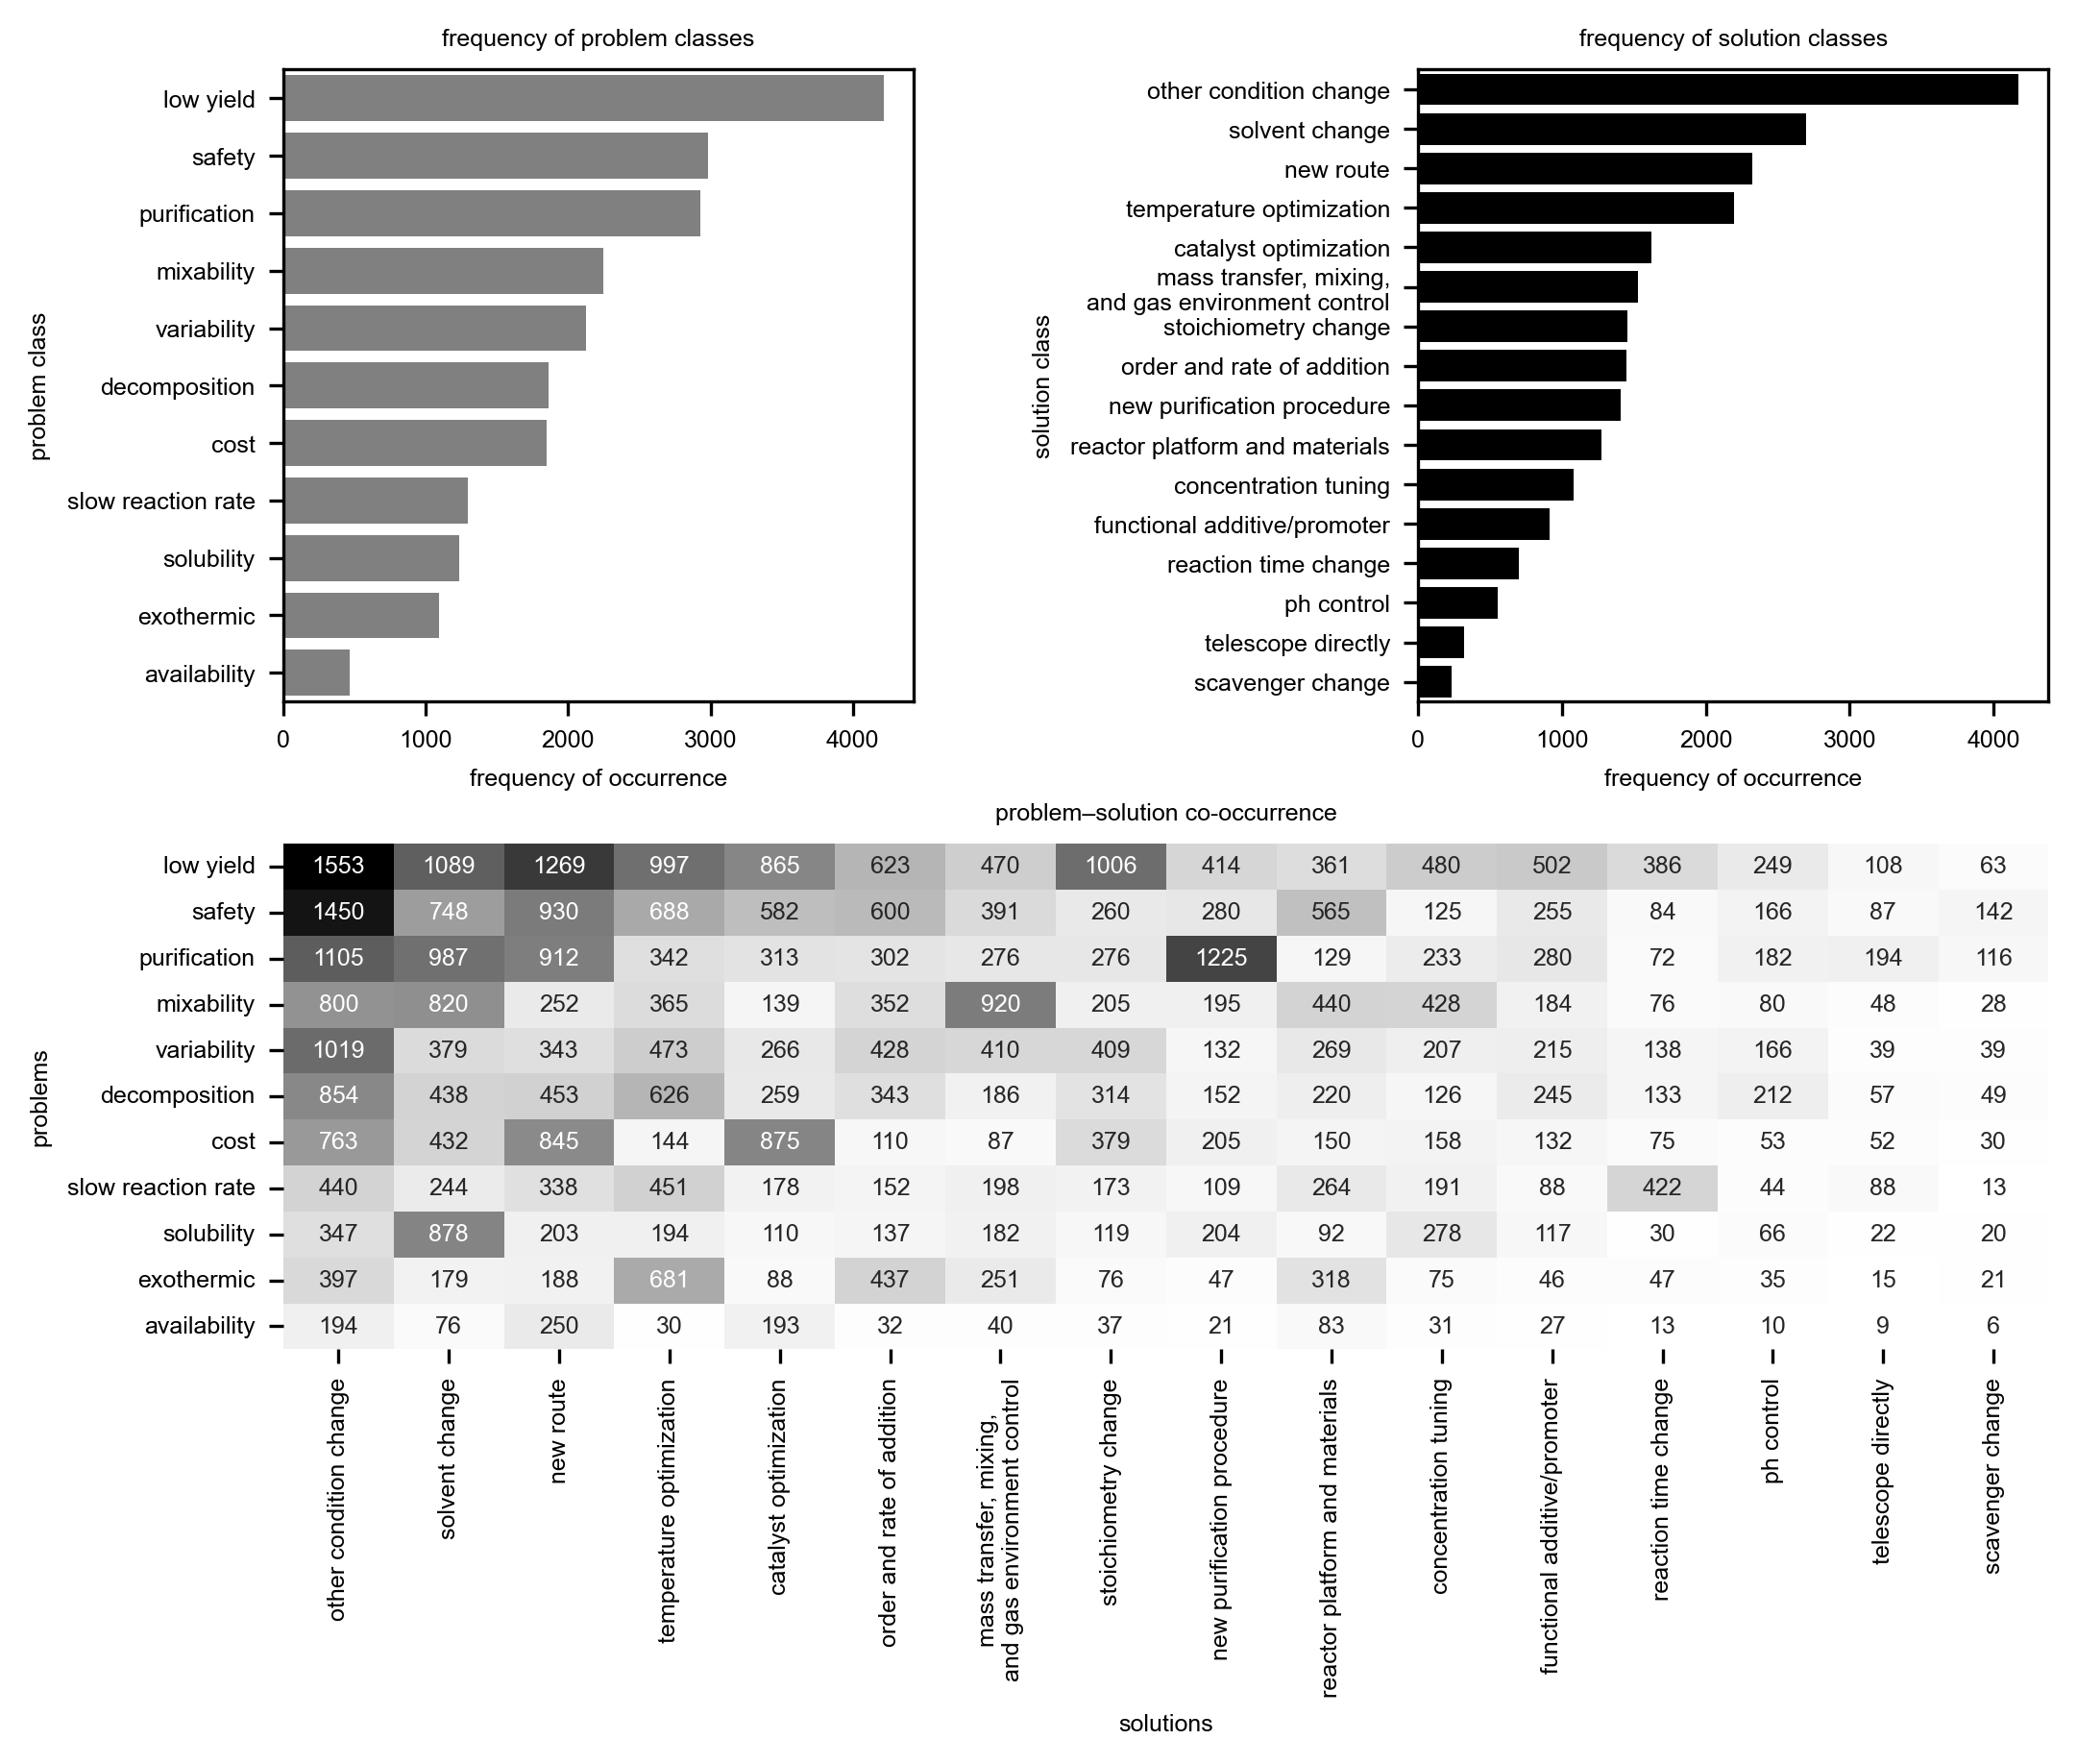

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

plt.rc('font', size=6)
plt.rc('font', family='Arial')

def clean_label(x):
    """remove brackets and lowercase the label"""
    if isinstance(x, str):
        return x.replace("[", "").replace("]", "").lower()
    return x

def plot_problem_distribution(df, top_n=100):
    df_copy = df.copy()

    # --- Clean labels in advance ---
    df_copy["Problems"] = df_copy["Problems"].apply(lambda lst: [x.replace("[LONG_REACTIONS]", "[SLOW REACTION RATE]") for x in lst])
    df_copy["Solutions"] = df_copy["Solutions"].apply(lambda lst: [x.replace("[MASS TRANSFER, MIXING, AND GAS ENVIRONMENT CONTROL]", "[MASS TRANSFER, MIXING,\nAND GAS ENVIRONMENT CONTROL]") for x in lst])
    df_copy["Problems"]  = df_copy["Problems"].apply(lambda lst: [clean_label(x) for x in lst] if isinstance(lst, list) else lst)
    df_copy["Solutions"] = df_copy["Solutions"].apply(lambda lst: [clean_label(x) for x in lst] if isinstance(lst, list) else lst)
    df_copy["Problems"] = df_copy["Problems"].apply(lambda lst: [x.replace("_", " ") for x in lst])
    df_copy["Solutions"] = df_copy["Solutions"].apply(lambda lst: [x.replace("_", " ") for x in lst])
    # --- Top Problems ---
    exploded_problems = explode_column(df_copy, "Problems")
    prob_counts = exploded_problems["Problems"].value_counts().head(top_n)

    # --- Top Solutions ---
    exploded_solutions = explode_column(df_copy, "Solutions")
    sol_counts = exploded_solutions["Solutions"].value_counts().head(top_n)

    # --- Problem–Solution co-occurrence ---
    exploded_both = df_copy.explode("Problems").explode("Solutions")
    exploded_both = exploded_both.dropna(subset=["Problems", "Solutions"])

    # clean index/columns after exploding
    exploded_both["Problems"]  = exploded_both["Problems"].apply(clean_label)
    exploded_both["Solutions"] = exploded_both["Solutions"].apply(clean_label)

    cross_tab = pd.crosstab(exploded_both["Problems"], exploded_both["Solutions"])
    top_problems = cross_tab.sum(axis=1).nlargest(top_n).index
    top_solutions = cross_tab.sum(axis=0).nlargest(top_n).index
    filtered = cross_tab.loc[top_problems, top_solutions]

    # --- Unified mosaic layout ---
    fig, axes = plt.subplot_mosaic(
        [["problems", "solutions"],
         ["heatmap",  "heatmap"]],
        figsize=(7, 6),
        dpi=300,
        gridspec_kw={"height_ratios": [2.5, 2], "wspace": 0.8, "hspace": 0.25},
    )

    ax_prob = axes["problems"]
    ax_sol = axes["solutions"]
    ax_heat = axes["heatmap"]

    # --- Top Problems ---
    sns.barplot(
        y=[clean_label(x) for x in prob_counts.index],
        x=prob_counts.values,
        ax=ax_prob,
        color="grey",
    )
    ax_prob.set_title("frequency of problem classes", fontsize=6)
    ax_prob.set_xlabel("frequency of occurrence", fontsize=6)
    ax_prob.set_ylabel("problem class", fontsize=6)

    # --- Top Solutions ---
    sns.barplot(
        y=[clean_label(x) for x in sol_counts.index],
        x=sol_counts.values,
        ax=ax_sol,
        color="black",
    )
    ax_sol.set_title("frequency of solution classes", fontsize=6)
    ax_sol.set_xlabel("frequency of occurrence", fontsize=6)
    ax_sol.set_ylabel("solution class", fontsize=6)

    # --- Heatmap (no colorbar) ---
    sns.heatmap(
        filtered.rename(index=clean_label, columns=clean_label),
        cmap="Greys",
        annot=True,
        fmt="d",
        ax=ax_heat,
        cbar=False,                # remove colorbar
    )
    ax_heat.set_title("problem–solution co-occurrence", fontsize=6)
    ax_heat.set_xlabel("solutions", fontsize=6)
    ax_heat.set_ylabel("problems", fontsize=6)

    # plt.tight_layout()
    fig.subplots_adjust(bottom=0.23, top=0.97, left=0.115, right=.99)

    plt.savefig('problem_solution_distribution.png', dpi=300, pad_inches=0.01)

plot_problem_distribution(df)

In [ ]:
problem_dict = {}

for k in df["Solutions"]:
    for j in k:
        problem_dict[j] = problem_dict.get(j, 0) + 1

sorted_problem_dict = sorted(problem_dict.items(), key=lambda x: x[1], reverse=True)
for jj in sorted_problem_dict:
    print(jj)


('[OTHER CONDITION CHANGE]', 4174)
('[SOLVENT CHANGE]', 2700)
('[NEW ROUTE]', 2324)
('[TEMPERATURE OPTIMIZATION]', 2196)
('[CATALYST OPTIMIZATION]', 1623)
('[MASS TRANSFER, MIXING, AND GAS ENVIRONMENT CONTROL]', 1529)
('[STOICHIOMETRY CHANGE]', 1455)
('[ORDER AND RATE OF ADDITION]', 1448)
('[NEW_PURIFICATION PROCEDURE]', 1408)
('[REACTOR PLATFORM AND MATERIALS]', 1276)
('[CONCENTRATION TUNING]', 1078)
('[FUNCTIONAL ADDITIVE/PROMOTER]', 915)
('[REACTION TIME CHANGE]', 699)
('[PH CONTROL]', 555)
('[TELESCOPE DIRECTLY]', 321)
('[SCAVENGER CHANGE]', 233)


In [9]:
problem_dict = {}

for k in df["Problems"]:
    for j in k:
        problem_dict[j] = problem_dict.get(j, 0) + 1

sorted_problem_dict = sorted(problem_dict.items(), key=lambda x: x[1], reverse=True)
for jj in sorted_problem_dict:
    print(jj)


('[LOW YIELD]', 4217)
('[SAFETY]', 2982)
('[PURIFICATION]', 2928)
('[MIXABILITY]', 2249)
('[VARIABILITY]', 2129)
('[DECOMPOSITION]', 1864)
('[COST]', 1852)
('[LONG_REACTIONS]', 1296)
('[SOLUBILITY]', 1236)
('[EXOTHERMIC]', 1090)
('[AVAILABILITY]', 467)
